# EDA: Resampling features to hourly

Quick look at the size, resolution and distributions of the kernel tables,
and a simple test of putting everything on one hourly grid.

In [16]:
import matplotlib.pyplot as plt
import pandas as pd

In [17]:
DATA = "data/kernel"

price = pd.read_csv(f"{DATA}/Historical_day_ahead_price_2015_2025.csv")
inflow = pd.read_csv(f"{DATA}/Historical_inflow_1958_2025.csv")
volume = pd.read_csv(f"{DATA}/Historical_volume_2015_2024.csv")
water = pd.read_csv(f"{DATA}/Synthetic_water_value_2015_2024.csv")
target = pd.read_csv(f"{DATA}/Unit_commitment_decisions.csv")

## How big is the data?

In [18]:
for name, df in [
    ("price", price),
    ("inflow", inflow),
    ("volume", volume),
    ("water", water),
    ("target", target),
]:
    print(f"{name:8s} rows={len(df):>8d}  cols={df.shape[1]:>4d}")

price    rows=  103062  cols=   2
inflow   rows=  594224  cols=  19
volume   rows=    3654  cols=  18
water    rows=    3654  cols=  18
target   rows=    2922  cols=2355


In [19]:
for name, df in [
    ("price", price),
    ("inflow", inflow),
    ("volume", volume),
    ("water", water),
]:
    ts = pd.to_datetime(df["date"], utc=True, format="mixed")
    print(f"{name:8s} {ts.min()}  ->  {ts.max()}")

price    2015-01-01 00:00:00+00:00  ->  2025-12-31 23:45:00+00:00
inflow   1958-01-01 00:00:00+00:00  ->  2025-10-15 07:00:00+00:00
volume   2015-01-01 00:00:00+00:00  ->  2025-01-01 00:00:00+00:00
water    2015-01-01 00:00:00+00:00  ->  2025-01-01 00:00:00+00:00


## What resolution is each table really?

In [20]:
for name, df in [
    ("price", price),
    ("inflow", inflow),
    ("volume", volume),
    ("water", water),
]:
    ts = pd.to_datetime(df["date"], utc=True, format="mixed").sort_values()
    print(name)
    print(ts.diff().value_counts().head(3))
    print()

price
date
0 days 01:00:00    94222
0 days 00:15:00     8839
Name: count, dtype: int64

inflow
date
0 days 01:00:00    594223
Name: count, dtype: int64

volume
date
1 days    3653
Name: count, dtype: int64

water
date
1 days    3653
Name: count, dtype: int64



## Price: hourly, with a 15-minute block at the very end

In [21]:
ts = pd.to_datetime(price["date"], utc=True, format="mixed").sort_values()
switch = ts[ts.diff() == pd.Timedelta("15min")].min()
print("15-minute prices start at:", switch)
print("rows after the switch:", (ts >= switch).sum())

15-minute prices start at: 2025-09-30 22:15:00+00:00
rows after the switch: 8839


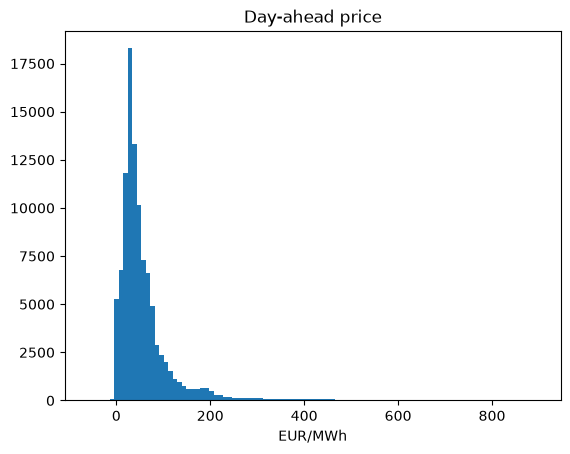

In [22]:
plt.hist(price["Day-ahead price (EUR/MWh)"].dropna(), bins=100)
plt.title("Day-ahead price")
plt.xlabel("EUR/MWh")
plt.show()

## Resample price to hourly (mean of the quarters)

In [23]:
p = price.copy()
p["date"] = pd.to_datetime(p["date"], utc=True, format="mixed")
p = p.set_index("date")["Day-ahead price (EUR/MWh)"].sort_index()

price_h = p.resample("1h").mean()
print(price_h.isna().sum(), "hours with no price at all")
price_h.tail()

0 hours with no price at all


date
2025-12-31 19:00:00+00:00    79.3625
2025-12-31 20:00:00+00:00    76.6875
2025-12-31 21:00:00+00:00    74.8775
2025-12-31 22:00:00+00:00    68.7650
2025-12-31 23:00:00+00:00    63.6850
Freq: h, Name: Day-ahead price (EUR/MWh), dtype: float64

In [24]:
# top-of-hour vs mean-of-quarters on the 15-minute block
block = p[switch:]
top = block[block.index.minute == 0]
mean = block.resample("1h").mean()

cmp = pd.DataFrame({"top_of_hour": top, "mean_4q": mean}).dropna()
print(
    "mean abs diff:", (cmp.top_of_hour - cmp.mean_4q).abs().mean().round(3), "EUR/MWh"
)
cmp.head()

mean abs diff: 2.776 EUR/MWh


,top_of_hour,mean_4q
date,,
2025-09-30 23:00:00+00:00,65.59,64.3350
2025-10-01 00:00:00+00:00,63.66,63.5200
2025-10-01 01:00:00+00:00,63.78,63.7525
2025-10-01 02:00:00+00:00,63.56,63.8350
2025-10-01 03:00:00+00:00,63.09,66.2350


## Inflow: hourly since 1958, but cases only start in 2015

In [25]:
ts = pd.to_datetime(inflow["date"], utc=True, format="mixed")
print("rows before 2015:", (ts < "2015").sum())
print("rows from  2015:", (ts >= "2015").sum())

rows before 2015: 499656
rows from  2015: 94568


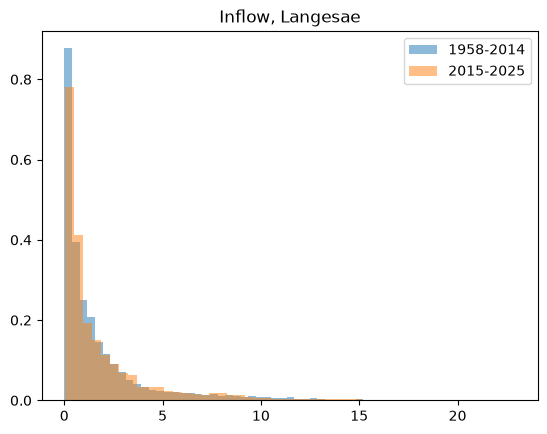

In [26]:
inf = inflow.copy()
inf["date"] = pd.to_datetime(inf["date"], utc=True, format="mixed")
inf = inf.set_index("date")

res = "Langesae"  # one reservoir as an example
old = inf[res][:"2014"]
new = inf[res]["2015":]

plt.hist(old, bins=50, alpha=0.5, density=True, label="1958-2014")
plt.hist(new, bins=50, alpha=0.5, density=True, label="2015-2025")
plt.legend()
plt.title(f"Inflow, {res}")
plt.show()

## The long history gives free seasonal normals (climatology)

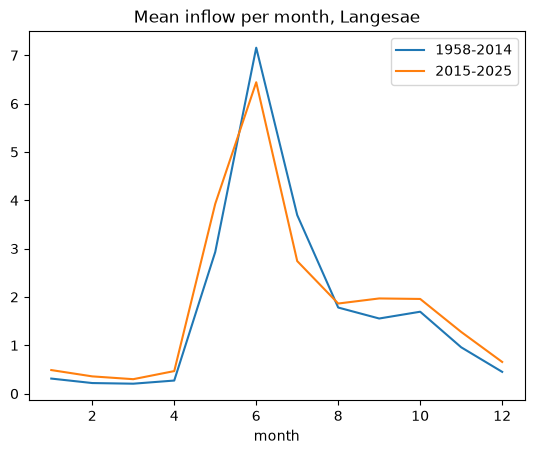

In [27]:
old_month = old.groupby(old.index.month).mean()
new_month = new.groupby(new.index.month).mean()

plt.plot(old_month, label="1958-2014")
plt.plot(new_month, label="2015-2025")
plt.legend()
plt.title(f"Mean inflow per month, {res}")
plt.xlabel("month")
plt.show()

## Daily tables: volume and water value

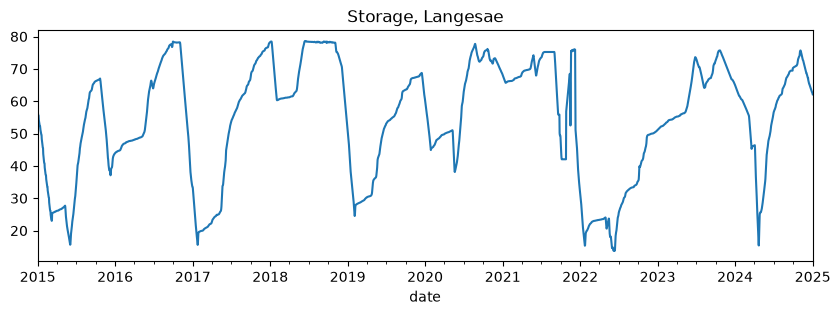

In [28]:
vol = volume.copy()
vol["date"] = pd.to_datetime(vol["date"], utc=True, format="mixed")
vol = vol.set_index("date")

vol[res].plot(title=f"Storage, {res}", figsize=(10, 3))
plt.show()

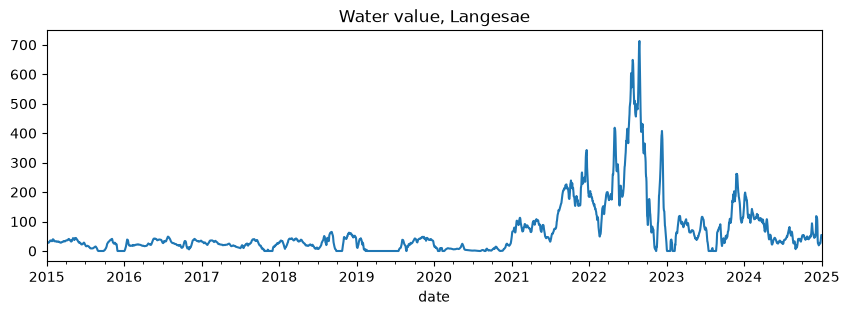

In [29]:
wv = water.copy()
wv["date"] = pd.to_datetime(wv["date"], utc=True, format="mixed")
wv = wv.set_index("date")

wv[res].plot(title=f"Water value, {res}", figsize=(10, 3))
plt.show()

## Target: how many cases, and how often is a unit ON?

In [30]:
print("cases:", len(target))
print("case starts:", target["starttime"].min(), "->", target["starttime"].max())

result_cols = [c for c in target.columns if c.startswith("result_committed")]
print("result columns:", len(result_cols), "(14 units x 168 hours)")
print("overall ON-rate:", target[result_cols].values.mean().round(3))

cases: 2922
case starts: 2015-01-01 -> 2022-12-31
result columns: 2352 (14 units x 168 hours)
overall ON-rate: 0.516


## Takeaways

- **Price**: hourly 2015 -> Sep 2025, then 15-minute. `resample("1h").mean()` handles both in one line.
- **Inflow**: hourly all the way back to 1958. The pre-2015 part is free climatology (seasonal normals).
- **Volume / water value**: daily, join on calendar day.
- **Target**: 2,922 cases, each 168 hours, 14 units. Everything can sit on one hourly grid.